# Homework 4

## Part a

Using a subset of the IMDB database (only the first 7000 words) we are going to make a model and plot the accuracy.  The model will have two layers of 16 neurons each, with a final layer of one neuron.  Using the model shown below, run it and plot the training loss and accuracy, and the validation loss and accuracy.  Use rmsprop optimizer, batch size = 512, twenty epochs and a 60/40 train/validation split.

In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc

#######################################################
# reduced number of words to 7000, from 10000, to speed training
# (train_data, train_labels), _ = imdb.load_data(num_words=10000)
# changed vectorize_squences to 5000 as well
# def vectorize_sequences(sequences, dimension=10000):

(train_data, train_labels), _ = imdb.load_data(num_words=7000)

def vectorize_sequences(sequences, dimension=7000):
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# Vectorize to binary bag-of-words
x_all = vectorize_sequences(train_data, dimension=7000)
y_all = np.asarray(train_labels).astype("float32")

# 60/40 train/validation split
N_TRAIN = int(0.60 * len(x_all))
x_train, y_train = x_all[:N_TRAIN], y_all[:N_TRAIN]
x_val,   y_val   = x_all[N_TRAIN:], y_all[N_TRAIN:]

/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
# add the compile and fit below
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_a = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

Epoch 1/20


/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-14 06:31:35.549063: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-10-14 06:31:35.549086: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-10-14 06:31:35.549090: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-10-14 06:31:35.549103: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-14 06:31:35.549113: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Creat

30/30 - 1s - 35ms/step - accuracy: 0.7483 - loss: 0.5445 - val_accuracy: 0.8586 - val_loss: 0.4077
Epoch 2/20
30/30 - 0s - 11ms/step - accuracy: 0.8827 - loss: 0.3430 - val_accuracy: 0.8827 - val_loss: 0.3200
Epoch 3/20
30/30 - 0s - 11ms/step - accuracy: 0.9095 - loss: 0.2631 - val_accuracy: 0.8776 - val_loss: 0.3012
Epoch 4/20
30/30 - 0s - 11ms/step - accuracy: 0.9243 - loss: 0.2161 - val_accuracy: 0.8902 - val_loss: 0.2789
Epoch 5/20
30/30 - 0s - 10ms/step - accuracy: 0.9337 - loss: 0.1892 - val_accuracy: 0.8823 - val_loss: 0.2958
Epoch 6/20
30/30 - 0s - 11ms/step - accuracy: 0.9476 - loss: 0.1608 - val_accuracy: 0.8814 - val_loss: 0.3022
Epoch 7/20
30/30 - 0s - 10ms/step - accuracy: 0.9495 - loss: 0.1492 - val_accuracy: 0.8829 - val_loss: 0.3008
Epoch 8/20
30/30 - 0s - 10ms/step - accuracy: 0.9564 - loss: 0.1326 - val_accuracy: 0.8732 - val_loss: 0.3409
Epoch 9/20
30/30 - 0s - 10ms/step - accuracy: 0.9632 - loss: 0.1191 - val_accuracy: 0.8762 - val_loss: 0.3464
Epoch 10/20
30/30 - 0

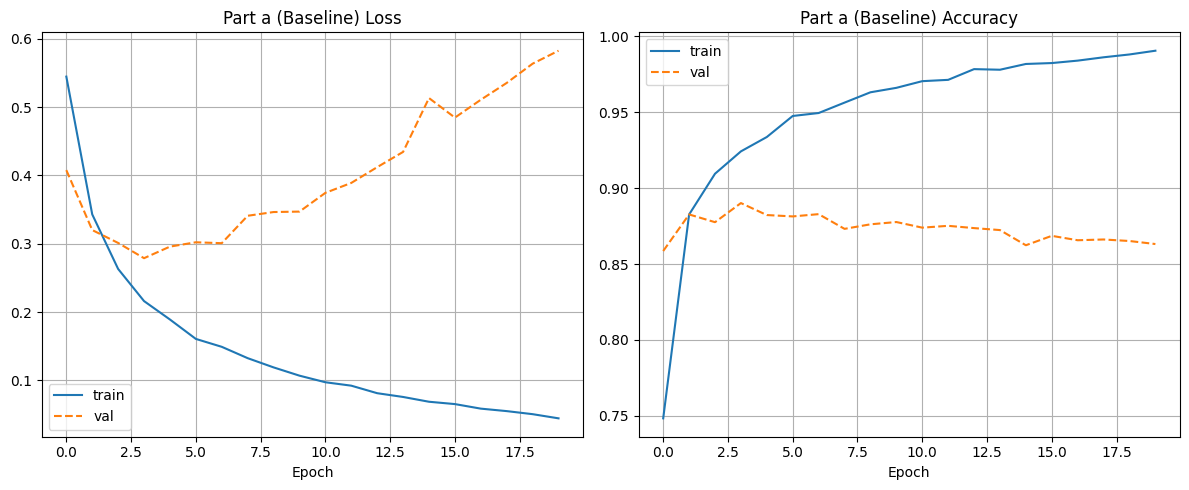

In [3]:
# code to plot the loss and accuracy goes here
def plot_history(hist, title_prefix=""):
    h = hist.history
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], '--', label="val")
    ax[0].set_title(f"{title_prefix} Loss"); ax[0].set_xlabel("Epoch"); ax[0].grid(True); ax[0].legend()
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], '--', label="val")
    ax[1].set_title(f"{title_prefix} Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].grid(True); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_a, title_prefix="Part a (Baseline)")

# Part b

This model appears to be overfitting.  Create a model with fewer neurons and see if that fixes overfitting.  Still run it out to 20 epochs.  Plot the loss and accuracy.

Epoch 1/20
30/30 - 1s - 31ms/step - accuracy: 0.6533 - loss: 0.6098 - val_accuracy: 0.7179 - val_loss: 0.5404
Epoch 2/20
30/30 - 0s - 11ms/step - accuracy: 0.7939 - loss: 0.4729 - val_accuracy: 0.7941 - val_loss: 0.4512
Epoch 3/20
30/30 - 0s - 11ms/step - accuracy: 0.8589 - loss: 0.3801 - val_accuracy: 0.8683 - val_loss: 0.3619
Epoch 4/20
30/30 - 0s - 12ms/step - accuracy: 0.8939 - loss: 0.3123 - val_accuracy: 0.8701 - val_loss: 0.3334
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.9124 - loss: 0.2658 - val_accuracy: 0.8830 - val_loss: 0.3013
Epoch 6/20
30/30 - 0s - 12ms/step - accuracy: 0.9282 - loss: 0.2294 - val_accuracy: 0.8820 - val_loss: 0.2915
Epoch 7/20
30/30 - 0s - 12ms/step - accuracy: 0.9383 - loss: 0.2035 - val_accuracy: 0.8787 - val_loss: 0.2972
Epoch 8/20
30/30 - 0s - 11ms/step - accuracy: 0.9453 - loss: 0.1835 - val_accuracy: 0.8797 - val_loss: 0.2992
Epoch 9/20
30/30 - 0s - 12ms/step - accuracy: 0.9529 - loss: 0.1653 - val_accuracy: 0.8829 - val_loss: 0.2966
Epoch 10/2

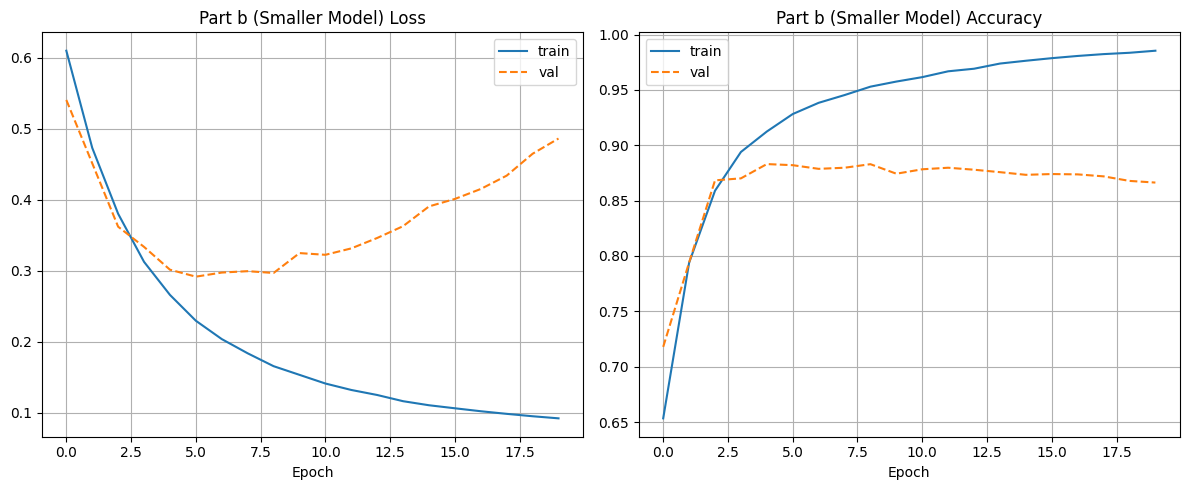

In [4]:
# Build a smaller network (8 units instead of 16)
small_model = keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(7000,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

small_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_b = small_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_b, title_prefix="Part b (Smaller Model)")
else:
    h = history_b.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part b — Loss"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part b — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()


# Part c

Go back to the original model, but use L1 regularization to see if that improves the model.  Plot loss and accuracy.  Use an L1 regularization penalty of 0.002.

Epoch 1/20
30/30 - 1s - 35ms/step - accuracy: 0.6777 - loss: 1.5449 - val_accuracy: 0.7876 - val_loss: 0.8383
Epoch 2/20
30/30 - 0s - 12ms/step - accuracy: 0.7849 - loss: 0.8054 - val_accuracy: 0.8016 - val_loss: 0.7855
Epoch 3/20
30/30 - 0s - 12ms/step - accuracy: 0.8175 - loss: 0.7559 - val_accuracy: 0.8165 - val_loss: 0.7510
Epoch 4/20
30/30 - 0s - 12ms/step - accuracy: 0.8325 - loss: 0.7182 - val_accuracy: 0.7491 - val_loss: 0.8074
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.8343 - loss: 0.6995 - val_accuracy: 0.8170 - val_loss: 0.7207
Epoch 6/20
30/30 - 0s - 12ms/step - accuracy: 0.8428 - loss: 0.6764 - val_accuracy: 0.8468 - val_loss: 0.6788
Epoch 7/20
30/30 - 0s - 11ms/step - accuracy: 0.8419 - loss: 0.6668 - val_accuracy: 0.8255 - val_loss: 0.6943
Epoch 8/20
30/30 - 0s - 12ms/step - accuracy: 0.8462 - loss: 0.6530 - val_accuracy: 0.8134 - val_loss: 0.7030
Epoch 9/20
30/30 - 0s - 12ms/step - accuracy: 0.8492 - loss: 0.6423 - val_accuracy: 0.8542 - val_loss: 0.6373
Epoch 10/2

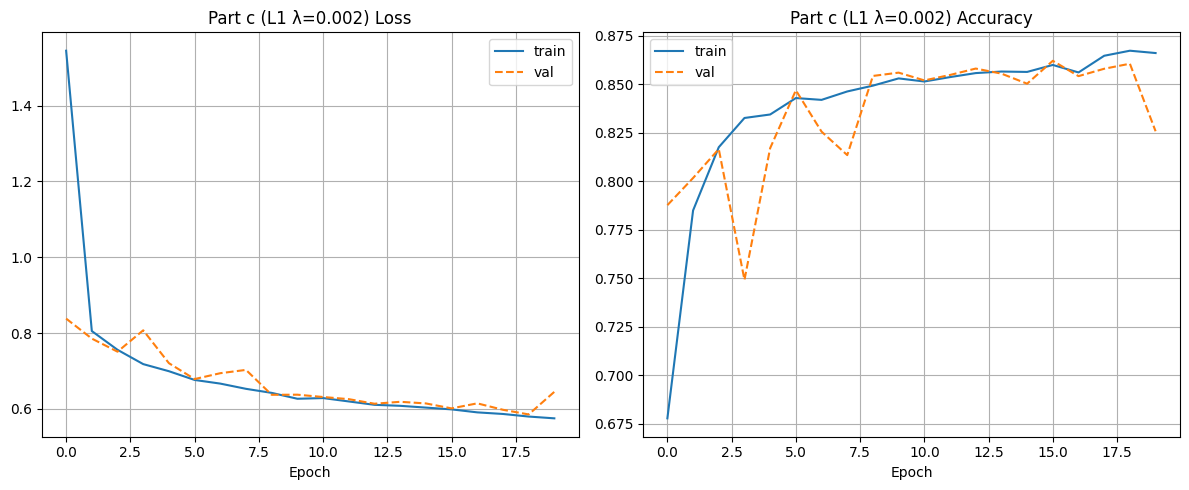

In [5]:
# Original-width model with L1 regularization
from tensorflow.keras import regularizers

l1_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,),
                 kernel_regularizer=regularizers.l1(0.002)),
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l1(0.002)),
    layers.Dense(1, activation="sigmoid")
])

l1_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_c = l1_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_c, title_prefix="Part c (L1 λ=0.002)")
else:
    h = history_c.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part c — Loss (L1 λ=0.002)"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part c — Accuracy (L1 λ=0.002)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

# Part d

Same as above, but use L2 regularization.  Use an L2 regularization penalty of 0.002.  Plot the loss and accuracy.

Epoch 1/20
30/30 - 1s - 32ms/step - accuracy: 0.7659 - loss: 0.6153 - val_accuracy: 0.8667 - val_loss: 0.4816
Epoch 2/20
30/30 - 0s - 12ms/step - accuracy: 0.8827 - loss: 0.4241 - val_accuracy: 0.8813 - val_loss: 0.4013
Epoch 3/20
30/30 - 0s - 12ms/step - accuracy: 0.9076 - loss: 0.3474 - val_accuracy: 0.8669 - val_loss: 0.3967
Epoch 4/20
30/30 - 0s - 13ms/step - accuracy: 0.9185 - loss: 0.3079 - val_accuracy: 0.8850 - val_loss: 0.3606
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.9275 - loss: 0.2844 - val_accuracy: 0.8648 - val_loss: 0.4017
Epoch 6/20
30/30 - 0s - 12ms/step - accuracy: 0.9345 - loss: 0.2694 - val_accuracy: 0.8826 - val_loss: 0.3670
Epoch 7/20
30/30 - 0s - 12ms/step - accuracy: 0.9345 - loss: 0.2588 - val_accuracy: 0.8822 - val_loss: 0.3598
Epoch 8/20
30/30 - 0s - 12ms/step - accuracy: 0.9408 - loss: 0.2517 - val_accuracy: 0.8818 - val_loss: 0.3706
Epoch 9/20
30/30 - 0s - 12ms/step - accuracy: 0.9461 - loss: 0.2384 - val_accuracy: 0.8812 - val_loss: 0.3697
Epoch 10/2

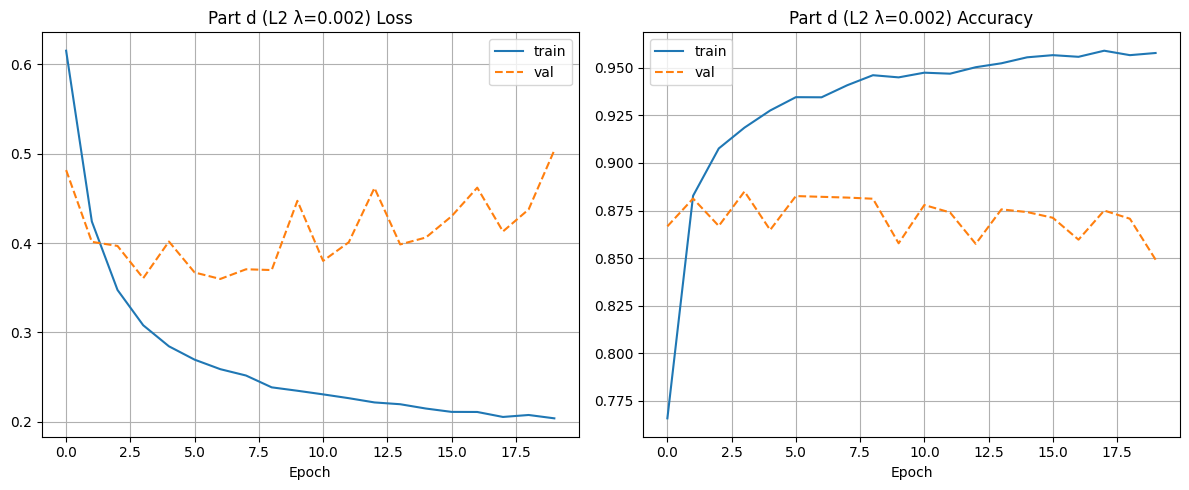

In [6]:
# Original-width model with L2 regularization
from tensorflow.keras import regularizers

l2_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,),
                 kernel_regularizer=regularizers.l2(0.002)),
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(0.002)),
    layers.Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_d = l2_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_d, title_prefix="Part d (L2 λ=0.002)")
else:
    h = history_d.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part d — Loss (L2 λ=0.002)"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part d — Accuracy (L2 λ=0.002)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

# Part e

Create an elastic net model (L1 and L2 regularization) using the same number of neurons and layers as above.  Use an L1 and L2 regularization penalty of 0.001.  Use lambda 0.001 for both.  Plot the loss and accuracy.

Epoch 1/20
30/30 - 1s - 40ms/step - accuracy: 0.6992 - loss: 1.1730 - val_accuracy: 0.8110 - val_loss: 0.7428
Epoch 2/20
30/30 - 0s - 12ms/step - accuracy: 0.8175 - loss: 0.6985 - val_accuracy: 0.8050 - val_loss: 0.6803
Epoch 3/20
30/30 - 0s - 12ms/step - accuracy: 0.8358 - loss: 0.6376 - val_accuracy: 0.8481 - val_loss: 0.6237
Epoch 4/20
30/30 - 0s - 12ms/step - accuracy: 0.8500 - loss: 0.5975 - val_accuracy: 0.8489 - val_loss: 0.5957
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.8580 - loss: 0.5684 - val_accuracy: 0.8418 - val_loss: 0.5846
Epoch 6/20
30/30 - 0s - 12ms/step - accuracy: 0.8585 - loss: 0.5464 - val_accuracy: 0.8573 - val_loss: 0.5500
Epoch 7/20
30/30 - 0s - 12ms/step - accuracy: 0.8629 - loss: 0.5306 - val_accuracy: 0.8521 - val_loss: 0.5523
Epoch 8/20
30/30 - 0s - 12ms/step - accuracy: 0.8709 - loss: 0.5121 - val_accuracy: 0.8647 - val_loss: 0.5236
Epoch 9/20
30/30 - 0s - 12ms/step - accuracy: 0.8707 - loss: 0.5074 - val_accuracy: 0.8648 - val_loss: 0.5155
Epoch 10/2

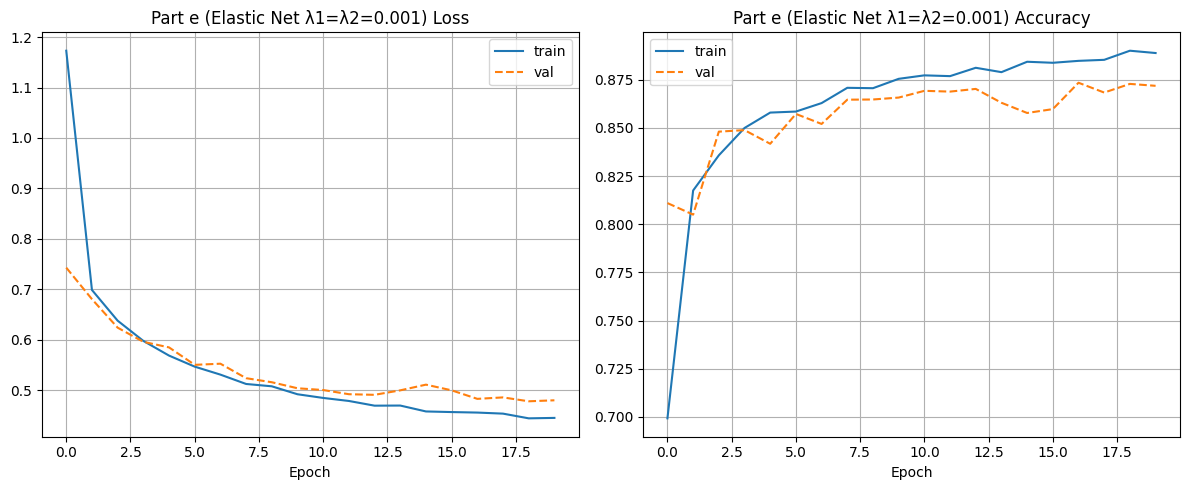

In [7]:
# Elastic Net
from tensorflow.keras.regularizers import L1L2

enet_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,),
                 kernel_regularizer=L1L2(l1=0.001, l2=0.001)),
    layers.Dense(16, activation="relu",
                 kernel_regularizer=L1L2(l1=0.001, l2=0.001)),
    layers.Dense(1, activation="sigmoid")
])

enet_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_e = enet_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_e, title_prefix="Part e (Elastic Net λ1=λ2=0.001)")
else:
    h = history_e.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part e — Loss (Elastic Net λ1=λ2=0.001)"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part e — Accuracy (Elastic Net λ1=λ2=0.001)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

# Part f

Use the model from part a and set 50% droputs between the layers.  Plot the loss and accuracy.

Epoch 1/20
30/30 - 1s - 36ms/step - accuracy: 0.6110 - loss: 0.6640 - val_accuracy: 0.7777 - val_loss: 0.5085
Epoch 2/20
30/30 - 0s - 13ms/step - accuracy: 0.7612 - loss: 0.4948 - val_accuracy: 0.8614 - val_loss: 0.3695
Epoch 3/20
30/30 - 0s - 12ms/step - accuracy: 0.8361 - loss: 0.3859 - val_accuracy: 0.8765 - val_loss: 0.3173
Epoch 4/20
30/30 - 0s - 12ms/step - accuracy: 0.8719 - loss: 0.3221 - val_accuracy: 0.8792 - val_loss: 0.2940
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.8911 - loss: 0.2852 - val_accuracy: 0.8843 - val_loss: 0.2864
Epoch 6/20
30/30 - 0s - 13ms/step - accuracy: 0.9081 - loss: 0.2537 - val_accuracy: 0.8847 - val_loss: 0.2844
Epoch 7/20
30/30 - 0s - 12ms/step - accuracy: 0.9171 - loss: 0.2313 - val_accuracy: 0.8868 - val_loss: 0.2909
Epoch 8/20
30/30 - 0s - 12ms/step - accuracy: 0.9217 - loss: 0.2203 - val_accuracy: 0.8841 - val_loss: 0.2974
Epoch 9/20
30/30 - 0s - 11ms/step - accuracy: 0.9273 - loss: 0.2097 - val_accuracy: 0.8835 - val_loss: 0.3051
Epoch 10/2

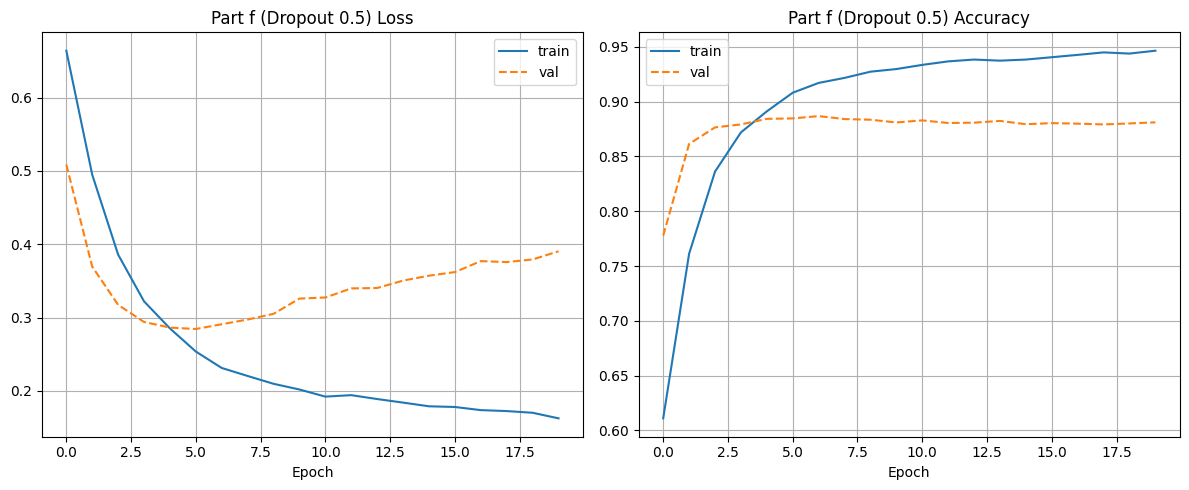

In [8]:
# Add 50% dropout between layers
drop_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,)),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

drop_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_f = drop_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=512,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_f, title_prefix="Part f (Dropout 0.5)")
else:
    h = history_f.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part f — Loss (Dropout 0.5)"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part f — Accuracy (Dropout 0.5)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

# Part g

Setup the model from part a, but use a variable learning rate.  Use the lr_schedule setup below for your learing rate.  Plot the loss and accuracy.

In [9]:
# Ensure we have train/val splits from Part a:
assert 'x_train' in globals() and 'y_train' in globals() and 'x_val' in globals() and 'y_val' in globals()

BATCH_SIZE = 512
EPOCHS = 20
N_TRAIN = len(x_train)                    # use the actual training split size from Part a
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE if N_TRAIN // BATCH_SIZE > 0 else 1

# Learning-rate schedule
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=STEPS_PER_EPOCH * 5,   # ~decay every 5 epochs
    decay_rate=1.0,
    staircase=False
)


This graph shows the variable learning rate at each epoch

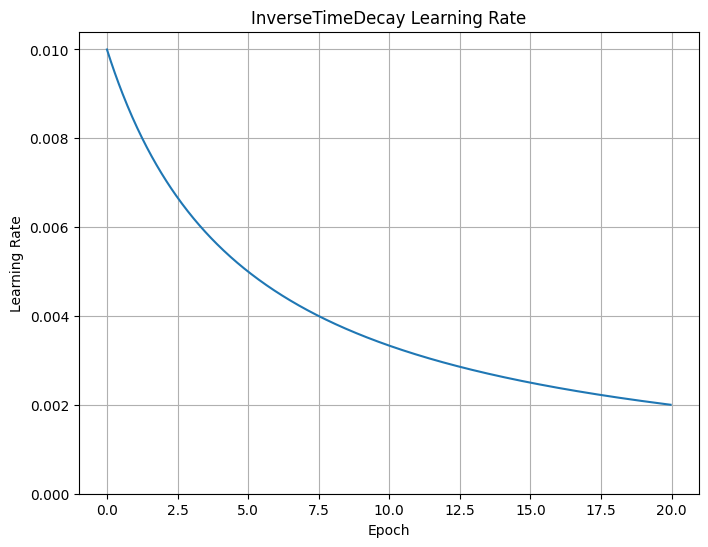

In [10]:
# This graph shows the variable learning rate at each epoch (approximate)
step = np.arange(STEPS_PER_EPOCH * EPOCHS)
lr = lr_schedule(step)
plt.figure(figsize=(8,6))
plt.plot(step / max(STEPS_PER_EPOCH, 1), lr)
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
_ = plt.ylabel('Learning Rate')
plt.title('InverseTimeDecay Learning Rate')
plt.grid(True)
plt.show()

Epoch 1/20
30/30 - 1s - 39ms/step - accuracy: 0.8407 - loss: 0.3715 - val_accuracy: 0.8827 - val_loss: 0.2989
Epoch 2/20
30/30 - 0s - 12ms/step - accuracy: 0.9385 - loss: 0.1730 - val_accuracy: 0.8808 - val_loss: 0.3229
Epoch 3/20
30/30 - 0s - 12ms/step - accuracy: 0.9565 - loss: 0.1214 - val_accuracy: 0.8760 - val_loss: 0.3805
Epoch 4/20
30/30 - 0s - 12ms/step - accuracy: 0.9719 - loss: 0.0890 - val_accuracy: 0.8663 - val_loss: 0.4685
Epoch 5/20
30/30 - 0s - 12ms/step - accuracy: 0.9795 - loss: 0.0696 - val_accuracy: 0.8636 - val_loss: 0.5324
Epoch 6/20
30/30 - 0s - 12ms/step - accuracy: 0.9841 - loss: 0.0540 - val_accuracy: 0.8630 - val_loss: 0.5983
Epoch 7/20
30/30 - 0s - 12ms/step - accuracy: 0.9892 - loss: 0.0406 - val_accuracy: 0.8615 - val_loss: 0.6655
Epoch 8/20
30/30 - 0s - 12ms/step - accuracy: 0.9941 - loss: 0.0269 - val_accuracy: 0.8608 - val_loss: 0.7299
Epoch 9/20
30/30 - 0s - 12ms/step - accuracy: 0.9971 - loss: 0.0189 - val_accuracy: 0.8567 - val_loss: 0.7967
Epoch 10/2

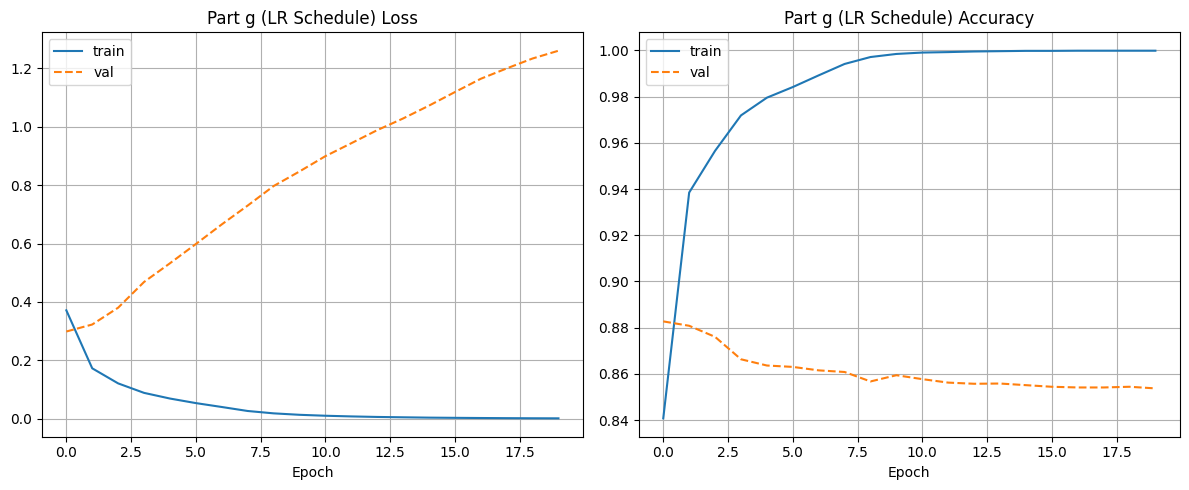

In [11]:
# Model from Part a with a variable learning rate (use Adam with schedule)
sched_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(7000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

sched_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_g = sched_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# Plot training/validation loss and accuracy
if 'plot_history' in globals():
    plot_history(history_g, title_prefix="Part g (LR Schedule)")
else:
    h = history_g.history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title("Part g — Loss (LR Schedule)"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title("Part g — Accuracy (LR Schedule)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

# Part h

Plot the validation accuracy of all the different models on a single plot with a legend.  Next, plot the validation loss of all the models on a single plot with a legend.

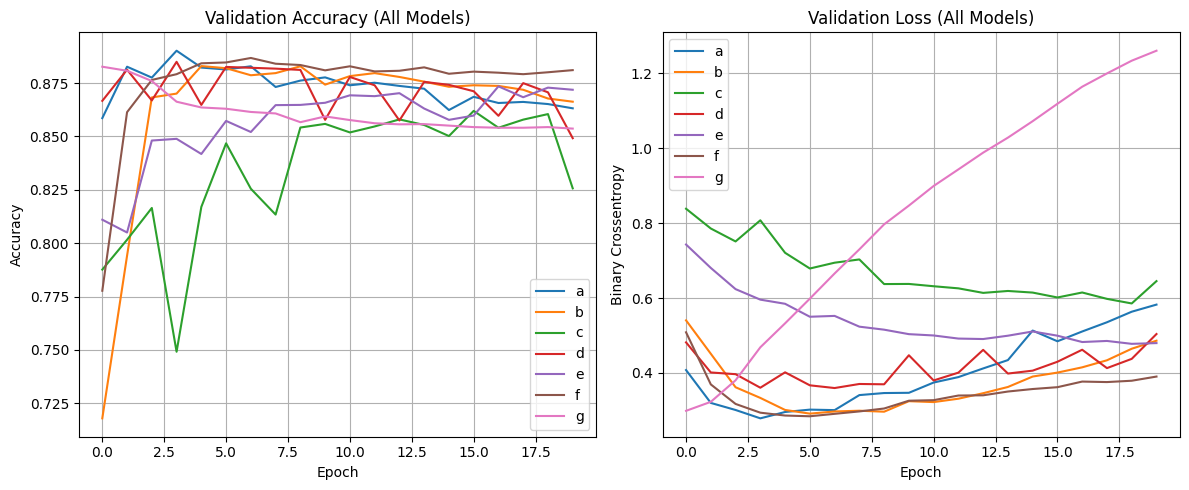

In [12]:
# Plot validation accuracy and validation loss for all models on single plots with legends.
histories = {}
for name in ["history_a","history_b","history_c","history_d","history_e","history_f","history_g"]:
    if name in globals() and isinstance(globals()[name].history, dict):
        histories[name] = globals()[name]

# Sanity check
if not histories:
    raise RuntimeError("No histories found. Run Parts a–g before Part h.")

# 1) Validation Accuracy plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for name, hist in histories.items():
    if "val_accuracy" in hist.history:
        plt.plot(hist.history["val_accuracy"], label=name.replace("history_",""))
plt.title("Validation Accuracy (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# 2) Validation Loss plot
plt.subplot(1,2,2)
for name, hist in histories.items():
    if "val_loss" in hist.history:
        plt.plot(hist.history["val_loss"], label=name.replace("history_",""))
plt.title("Validation Loss (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Part i

Use any combination of the techniques above (more or less neurons, regularization, learning rate, dropout, and any changes to hyperparameters) to create the best validation accuracy model you can.  You must create at least 5 different models.  The final model must be better than any of the models above for full credit.


Training i1_wide32x2_l2_1e-4_do_0.3 ...
Epoch 1/30
30/30 - 1s - 47ms/step - accuracy: 0.6724 - loss: 0.6064 - val_accuracy: 0.8492 - val_loss: 0.4338
Epoch 2/30
30/30 - 0s - 15ms/step - accuracy: 0.8502 - loss: 0.3731 - val_accuracy: 0.8778 - val_loss: 0.3095
Epoch 3/30
30/30 - 0s - 15ms/step - accuracy: 0.9035 - loss: 0.2617 - val_accuracy: 0.8857 - val_loss: 0.2896
Epoch 4/30
30/30 - 0s - 14ms/step - accuracy: 0.9289 - loss: 0.2109 - val_accuracy: 0.8856 - val_loss: 0.2987
Epoch 5/30
30/30 - 0s - 14ms/step - accuracy: 0.9397 - loss: 0.1815 - val_accuracy: 0.8830 - val_loss: 0.3196
Epoch 6/30
30/30 - 0s - 14ms/step - accuracy: 0.9529 - loss: 0.1589 - val_accuracy: 0.8845 - val_loss: 0.3382

Training i2_bn16x2_do_0.4 ...
Epoch 1/30
30/30 - 2s - 62ms/step - accuracy: 0.6136 - loss: 0.6791 - val_accuracy: 0.7606 - val_loss: 0.6528
Epoch 2/30
30/30 - 1s - 17ms/step - accuracy: 0.7609 - loss: 0.5078 - val_accuracy: 0.8279 - val_loss: 0.6025
Epoch 3/30
30/30 - 1s - 17ms/step - accuracy: 0.

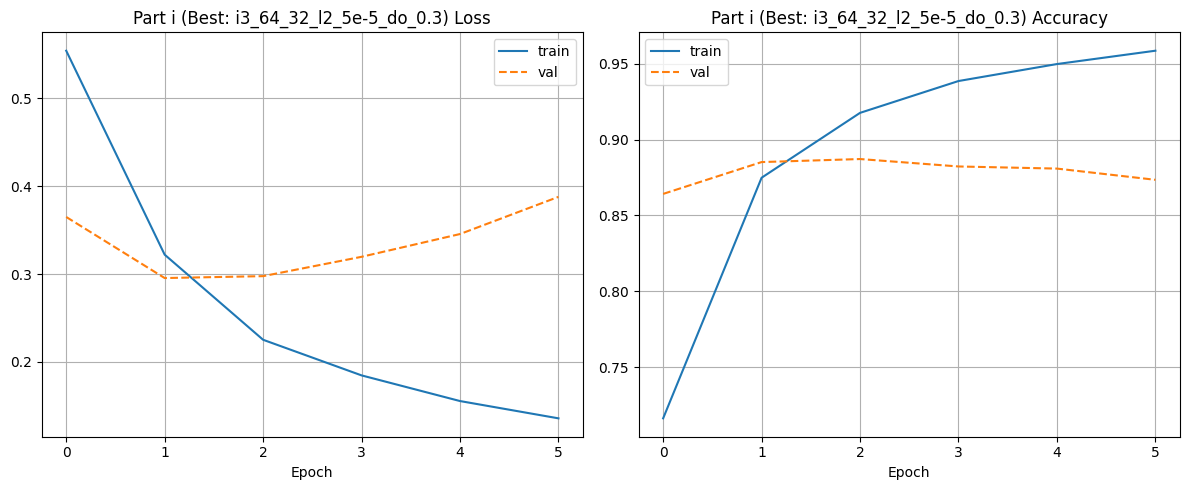

In [13]:
assert 'x_train' in globals() and 'y_train' in globals() and 'x_val' in globals() and 'y_val' in globals(), \
    "Run Parts a–g first to create train/val splits."

EPOCHS = 30
BATCH_SIZE = 512

# If an LR schedule from Part g isn't defined, define one here (same shape as Part g).
if 'lr_schedule' not in globals():
    N_TRAIN_i = len(x_train)
    STEPS_PER_EPOCH_i = max(1, N_TRAIN_i // BATCH_SIZE)
    lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=0.01,
        decay_steps=STEPS_PER_EPOCH_i * 5,
        decay_rate=1.0,
        staircase=False
    )

early_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True
)

def build_variant(units1=16, units2=16, act="relu",
                  l1=0.0, l2=0.0, dropout=0.0, batchnorm=False,
                  use_lr_schedule=False):
    layers_list = []

    # First dense
    if batchnorm:
        layers_list += [
            layers.Dense(units1, use_bias=False, input_shape=(7000,),
                         kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
            layers.BatchNormalization(),
            layers.Activation(act)
        ]
    else:
        layers_list += [
            layers.Dense(units1, activation=act, input_shape=(7000,),
                         kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2))
        ]

    if dropout > 0:
        layers_list.append(layers.Dropout(dropout))

    # Second dense
    if batchnorm:
        layers_list += [
            layers.Dense(units2, use_bias=False,
                         kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
            layers.BatchNormalization(),
            layers.Activation(act)
        ]
    else:
        layers_list += [
            layers.Dense(units2, activation=act,
                         kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2))
        ]

    if dropout > 0:
        layers_list.append(layers.Dropout(dropout))

    # Output
    layers_list += [layers.Dense(1, activation="sigmoid")]

    model = keras.Sequential(layers_list)

    opt = keras.optimizers.Adam(learning_rate=lr_schedule if use_lr_schedule else 1e-3)
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# ----- Define at least 5 distinct model configurations -----
configs = [
    # i1: wider with mild L2 + moderate dropout
    dict(name="i1_wide32x2_l2_1e-4_do_0.3",
         units1=32, units2=32, l1=0.0, l2=1e-4, dropout=0.3, batchnorm=False, use_lr_schedule=False),

    # i2: batch norm + dropout (regularizes activations)
    dict(name="i2_bn16x2_do_0.4",
         units1=16, units2=16, l1=0.0, l2=0.0, dropout=0.4, batchnorm=True, use_lr_schedule=False),

    # i3: deeper capacity 64→32 with mild L2 + dropout
    dict(name="i3_64_32_l2_5e-5_do_0.3",
         units1=64, units2=32, l1=0.0, l2=5e-5, dropout=0.3, batchnorm=False, use_lr_schedule=False),

    # i4: small but strong regularization (bias–variance shift)
    dict(name="i4_8x2_l2_5e-4_do_0.5",
         units1=8, units2=8, l1=0.0, l2=5e-4, dropout=0.5, batchnorm=False, use_lr_schedule=False),

    # i5: original width but with inverse-time LR schedule
    dict(name="i5_16x2_lr_sched",
         units1=16, units2=16, l1=0.0, l2=0.0, dropout=0.0, batchnorm=False, use_lr_schedule=True),

    # (optional 6th) elastic net + slight dropout + wider
    dict(name="i6_32_16_enet_1e-4_do_0.2",
         units1=32, units2=16, l1=1e-4, l2=1e-4, dropout=0.2, batchnorm=False, use_lr_schedule=False),
]

# ----- Train each variant and store histories -----
hist_i = {}
models_i = {}

for cfg in configs:
    print(f"\nTraining {cfg['name']} ...")
    m = build_variant(**{k:v for k,v in cfg.items() if k != 'name'})
    h = m.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_cb],
        verbose=2
    )
    models_i[cfg['name']] = m
    hist_i[cfg['name']] = h

# ----- Build a leaderboard by max validation accuracy -----
def max_val_acc(history):
    return float(np.max(history.history.get("val_accuracy", [0.0])))

leaderboard_i = sorted([(name, max_val_acc(h)) for name, h in hist_i.items()],
                       key=lambda x: x[1], reverse=True)

print("\nPart i — Validation Accuracy Leaderboard:")
for name, acc in leaderboard_i:
    print(f"{name:>28}: {acc:.4f}")

best_i_name, best_i_acc = leaderboard_i[0]
best_i_model = models_i[best_i_name]

# ----- (Optional) Compare against earlier models' best val accuracy -----
prev_histories = [v for k, v in globals().items() if k.startswith("history_") and hasattr(v, "history")]
prev_best = 0.0
for h in prev_histories:
    prev_best = max(prev_best, float(np.max(h.history.get("val_accuracy", [0.0]))))

print(f"\nBest previous (Parts a–g) val acc: {prev_best:.4f}")
print(f"Best Part i model: {best_i_name} with val acc = {best_i_acc:.4f}")

# Plot the best Part i model curves
if 'plot_history' in globals():
    plot_history(hist_i[best_i_name], title_prefix=f"Part i (Best: {best_i_name})")
else:
    h = hist_i[best_i_name].history
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], '--', label="val")
    plt.title(f"Part i — Loss ({best_i_name})"); plt.xlabel("Epoch"); plt.ylabel("Binary Crossentropy")
    plt.grid(True); plt.legend()
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], '--', label="val")
    plt.title(f"Part i — Accuracy ({best_i_name})"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()


In [14]:
# Compare best val accuracy: earlier (a–g) vs. Part i variants
def max_val_acc(hist): 
    return float(np.max(hist.history.get("val_accuracy", [0.0])))

prev_histories = [h for n,h in globals().items() if n in
                  ["history_a","history_b","history_c","history_d","history_e","history_f","history_g"]]
prev_best = max(max_val_acc(h) for h in prev_histories)

# hist_i and models_i were created in Part i
parti_best = max(max_val_acc(h) for h in hist_i.values())

print(f"Best previous (a–g) val acc : {prev_best:.4f}")
print(f"Best Part i val acc         : {parti_best:.4f}")
print("Improved over a–g?          :", parti_best > prev_best)

Best previous (a–g) val acc : 0.8902
Best Part i val acc         : 0.8872
Improved over a–g?          : False
